# Qwen3.5-4B MLE-bench Evaluation Analysis

Model: Qwen/Qwen3.5-4B via vLLM (RolloutClient text mode)

Task: mlsp-2013-birds (64 samples)

In [1]:
import sys
sys.path.insert(0, "/home/winnieyangwn/rllm")
import importlib

import analysis.utils.eval_utils as eval_utils 

importlib.reload(eval_utils)
from analysis.utils.eval_utils import *

/storage/home/winnieyangwn/miniforge3/envs/aira-dojo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_path = "/checkpoint/maui_sft/winnieyangwn/rllm/eval/qwen4b_vllm_test/results/trajectories.jsonl"

In [3]:
import pandas as pd

df = pd.read_json(data_path, lines=True)
print(f"Loaded {len(df)} trajectories")

Loaded 64 trajectories


Found 0 rollouts matching valid criteria
Found 64 rollouts matching invalid criteria (excluding infra errors)
Found 0 rollouts with infrastructure errors


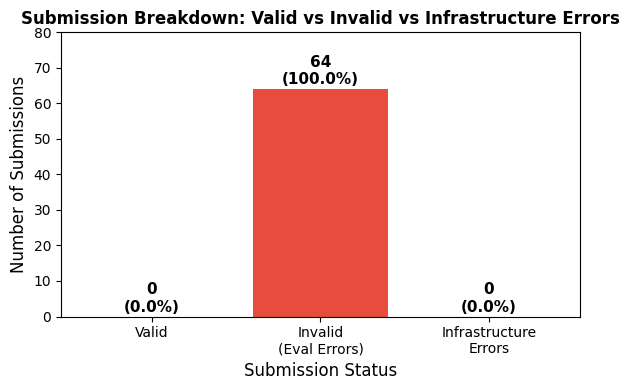

In [4]:
valid_df, invalid_df, infra_df = plot_submission_validity_breakdown(df)

Analyzing 64 rows for invalid submissions...
Found 64 invalid submissions

ERROR CATEGORY DISTRIBUTION


,Count,Percentage
Error Category,,
Context Length Exceeded,64,100.0



Total: 64

ROLLOUT INDICES BY ERROR CATEGORY


,Error Category,Count,Rollout Indices
0,Context Length Exceeded,64,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."


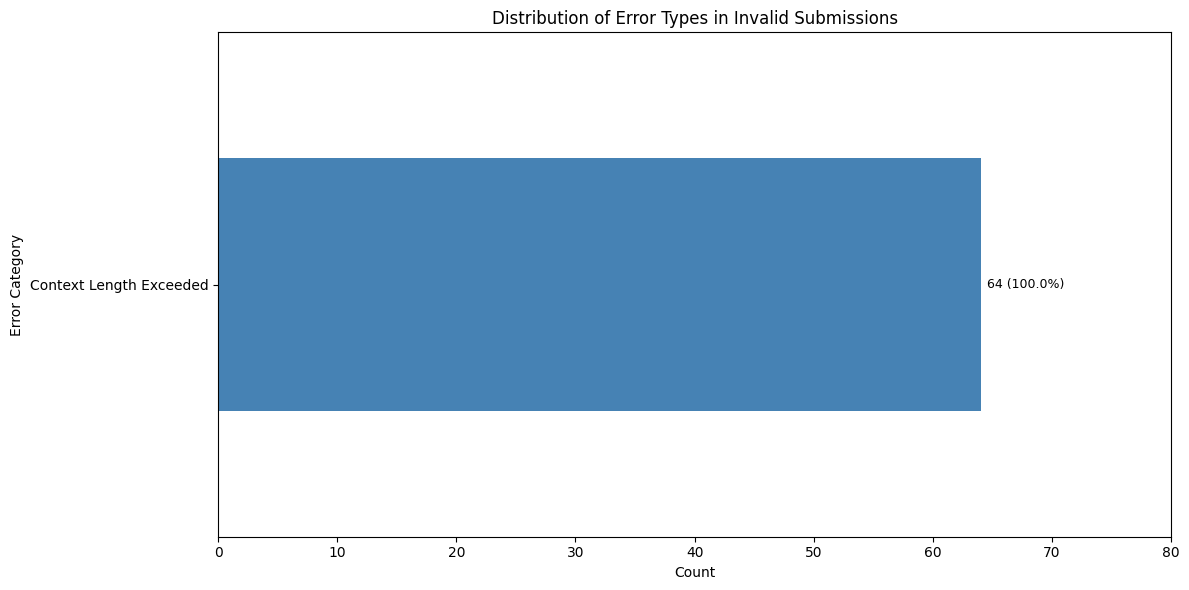


ERROR CATEGORY PERCENTAGE
Context Length Exceeded: 100.0%


In [5]:
# First analyze invalid submissions
df_errors, summary_df, rollout_indices_df = analyze_invalid_submissions(df)

# Then plot the distribution
error_counts, error_pct = plot_invalid_error_distribution(df_errors)

In [6]:
# Test process_df function
importlib.reload(eval_utils)
from analysis.utils.eval_utils import process_df

df_processed, df_task = process_df(df, Ks=[1, 4, 8, 16, 24, 32, 40, 48, 56, 64])

print("=== df_processed (rollout-level) ===")
print(f"Shape: {df_processed.shape}")


print("\n\n=== df_task (task-level) ===")
print(f"Shape: {df_task.shape}")
display(df_task)

=== df_processed (rollout-level) ===
Shape: (64, 17)


=== df_task (task-level) ===
Shape: (1, 28)


,n_rollouts,pass@1,pass@4,pass@8,pass@16,pass@24,pass@32,pass@40,pass@48,pass@56,...,valid_pass@48,valid_pass@56,valid_pass@64,any_medal_rate,gold_medal_rate,silver_medal_rate,bronze_medal_rate,gold_threshold,silver_threshold,bronze_threshold
task_name,,,,,,,,,,,,,,,,,,,,,
mlsp-2013-birds,64,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.907407,0.808642,0.611111


In [7]:
get_summary_stats(df)

{'total': 64,
 'valid_submissions': 0,
 'valid_rate': np.float64(0.0),
 'passed': 0,
 'pass_rate': np.float64(0.0),
 'avg_percentile': np.float64(0.0),
 'min_percentile': np.float64(0.0),
 'max_percentile': np.float64(0.0)}

In [8]:
df.shape

(64, 9)

Using pre-computed pass@k for 1 tasks
Tasks: ['mlsp-2013-birds']


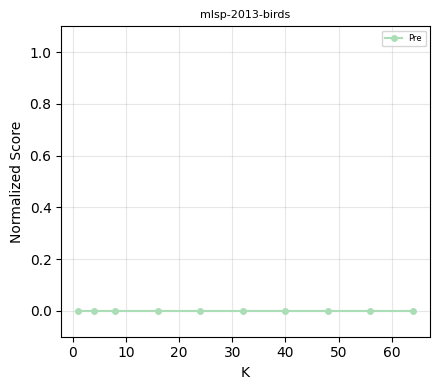

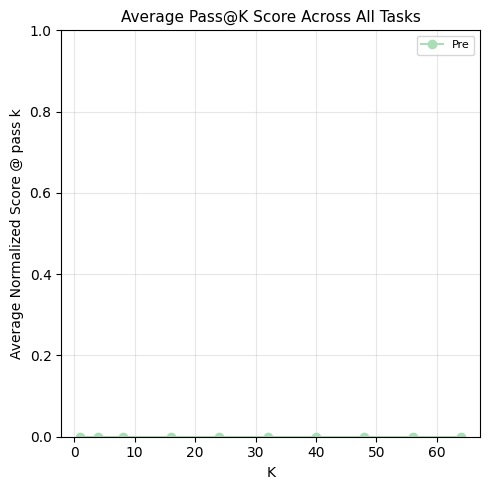

K	Pre
1	0.0000
4	0.0000
8	0.0000
16	0.0000
24	0.0000
32	0.0000
40	0.0000
48	0.0000
56	0.0000
64	0.0000


In [9]:
# Test pass@k for percentile scores
results_df = plot_pass_at_k(df_task, metric="percentile")

In [10]:
# Compare metrics across the full dataset
plot_metric_comparison([df_processed], labels=["Qwen3.5-4B"], metric="percentile", agg="mean")


plot_metric_comparison([df_processed], labels=["Qwen3.5-4B"], metric="medal", agg="mean")

Mean Percentile Qwen3.5-4B: 0.0000 ± 0.0000


Mean Any Medal Qwen3.5-4B: 0.0000 ± 0.0000
Mean Gold Medal Qwen3.5-4B: 0.0000 ± 0.0000
Mean Silver Medal Qwen3.5-4B: 0.0000 ± 0.0000
Mean Bronze Medal Qwen3.5-4B: 0.0000 ± 0.0000


({'any_medal': {'values': [np.float64(0.0)], 'stds': [np.float64(0.0)]},
  'gold_medal': {'values': [np.float64(0.0)], 'stds': [np.float64(0.0)]},
  'silver_medal': {'values': [np.float64(0.0)], 'stds': [np.float64(0.0)]},
  'bronze_medal': {'values': [np.float64(0.0)], 'stds': [np.float64(0.0)]}},
 None)